## Understanding the Diffusion Models

In RFDiffusion, we encounter the modification (or fine-tuning) the RFDiffusion network for Diffusion tasks. To understand this process, we need to first understand the concept of diffusion models.

### Forward Diffusion process

Data is said to 'follow' a distribution $\mathbf{x}_0 \sim q(\mathbf{x})$. For example, the following image of the imagined cytoplasm of a bacteria. We will work with the resized image of the cartoon since it's easier.

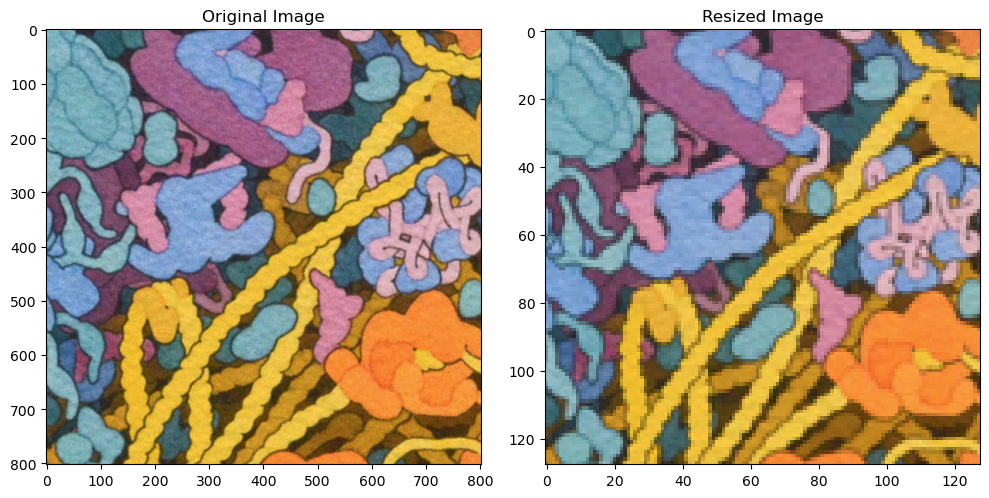

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('./Markdown/bacteria_inners.png')
resized_img = img.resize((128, 128))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[1].imshow(resized_img)
ax[1].set_title('Resized Image')
plt.tight_layout()
plt.show()


In the forward diffusion process, Gaussian noise is added to the data in a $T$ steps. The product of this process is a sequence of noisy images (samples) $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_T$. This step is controlled by a variance schedule $0 < \beta_1 \leq \beta_2 ... \leq \beta_t < 1$.

And the forward diffusion process is defined as:
$$ q(\mathbf{x}_t | \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t \mathbf{I}) $$

where $\mathcal{N}$ is the Gaussian distribution.

And the joint distribution of the forward diffusion process is:
$$ q(\mathbf{x}_{0:T} | \mathbf{x}_0) = q(\mathbf{x}_1, \ldots, \mathbf{x}_T | \mathbf{x}_0) = \prod_{t=1}^T q(\mathbf{x}_t | \mathbf{x}_{t-1}) $$

In [ ]:
import numpy as np

# Add Gaussian noise to the image for 100 times
def add_gaussian_noise(image, num_steps=100, beta=0.01):
    step_size = num_steps // 10
    beta = 0.01  # Variance schedule, for simplicity we use a constant value
    noisy_images = []
    for t in range(num_steps):
        noise = np.random.normal(0, np.sqrt(beta), image.shape)
        noisy_image = image + noise
        noisy_image = np.clip(noisy_image, 0, 1)  # Ensure pixel values are in [0, 1]
        if t % step_size == 0: 
            noisy_images.append(image * 255)
        image = noisy_image

    # Display the noisy images
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        if i < len(noisy_images):
            ax.imshow(noisy_images[i], cmap='gray')
            ax.set_title(f'Step {i * step_size}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

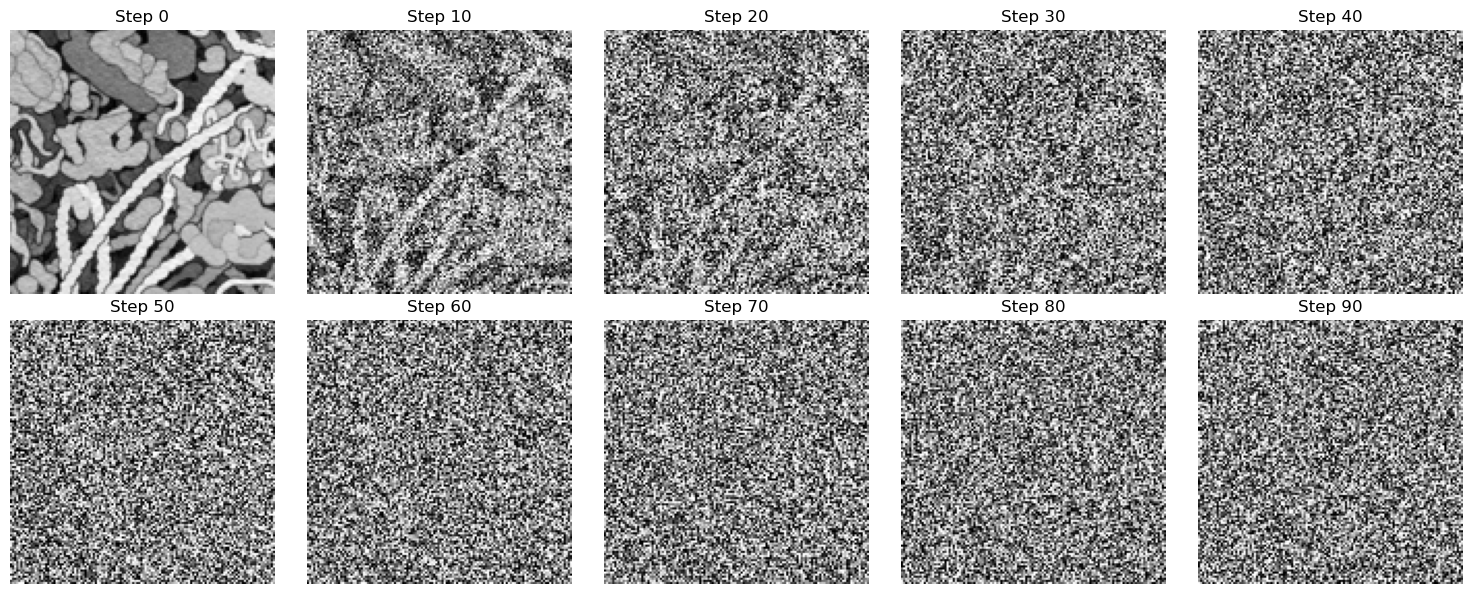

CPU times: user 389 ms, sys: 18.8 ms, total: 407 ms
Wall time: 408 ms


In [ ]:
# Change the image to grayscale
img_gray = resized_img.convert('L')
img_gray = np.array(img_gray)
img_gray = img_gray / 255.0  # Normalize the image to [0, 1]

add_gaussian_noise(img_gray, num_steps=100, beta=0.01)

### Simplifying Calculation

To calculate the addition of noise in every step is quite complex. We can simplify this process with a reparameterization trick, thanks to the properties of Gaussian distributions. Let $ \alpha_t = 1 - \beta_t $ and $ \bar{\alpha}_t = \prod_{s=1}^t \alpha_s $. 

Then we can rewrite the forward diffusion process as:

$$
\begin{aligned}
\mathbf{x}_t &= \sqrt{\alpha_t} \mathbf{x}_{t - 1} + \sqrt{1 - \alpha_t} \, \mathbf{\epsilon}_{t - 1} \\
&= \sqrt{\alpha_t \alpha_{t-1}} \mathbf{x}_{t-2} + \sqrt{1 - \alpha_t \alpha_{t-1}} \bar{\boldsymbol{\epsilon}}_{t-2}  ^{(*)} \\
&= \dots \\
&= \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon} \\
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, (1 - \bar{\alpha}_t)\mathbf{I})

\end{aligned}
$$

where $\epsilon_t \sim \mathcal{N}(0, \mathbf{I})$ is a Gaussian noise.

$(*)$ Involves merging two Gaussian distributions. Recall that the merge of two $\mathcal{N}(\mu_1, \sigma_1^2)$ and $\mathcal{N}(\mu_2, \sigma_2^2)$ is $\mathcal{N}(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)$.

With this simplification, we expect a quicker addition of noise in the forward diffusion process.

In [31]:
def fast_add_gaussian_noise(image, num_steps=1000, beta=0.001):
    bar_alpha = (1 - beta) ** (num_steps)
    noise = np.random.normal(0, np.sqrt(1 - bar_alpha), image.shape)
    noisy_image = np.sqrt(bar_alpha) * image + noise
    noisy_image = np.clip(noisy_image, 0, 1)  # Ensure pixel values are in [0, 1]
    
    plt.imshow(noisy_image, cmap='gray')
    plt.title('Noisy Image')
    plt.axis('off')
    plt.show()

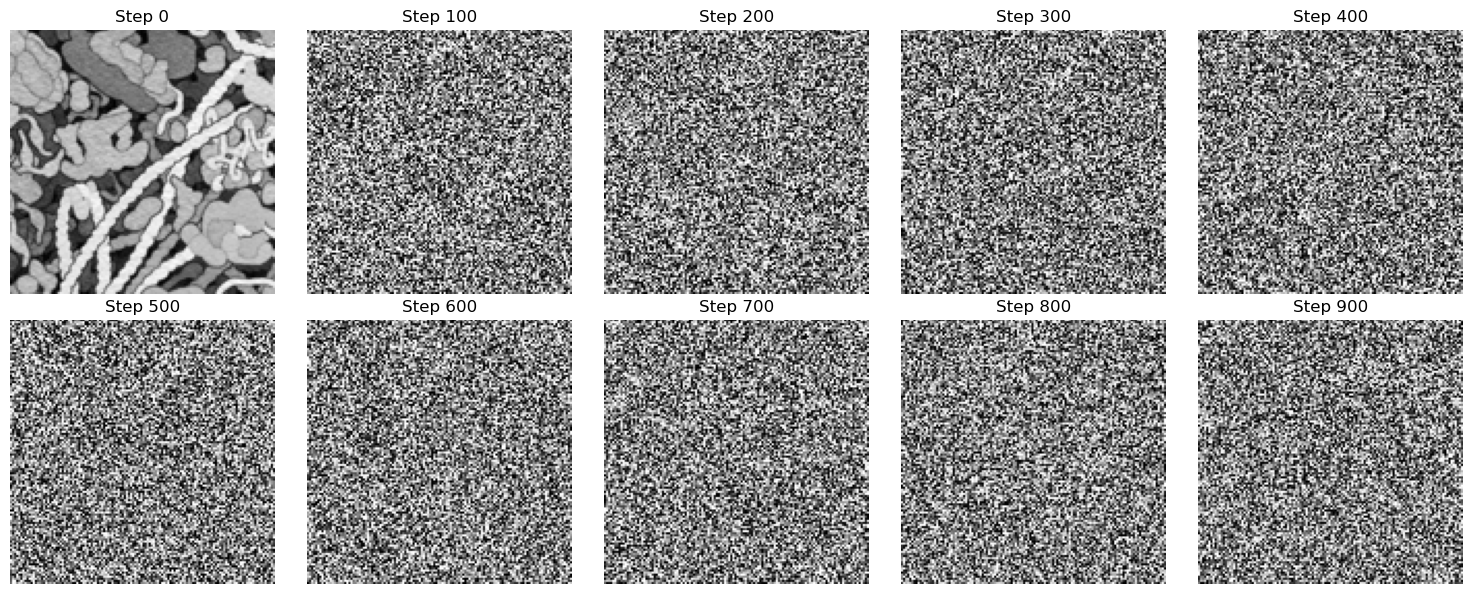

CPU times: user 647 ms, sys: 22.8 ms, total: 669 ms
Wall time: 677 ms


In [32]:
%%time

add_gaussian_noise(img_gray, num_steps=1000, beta=0.001)

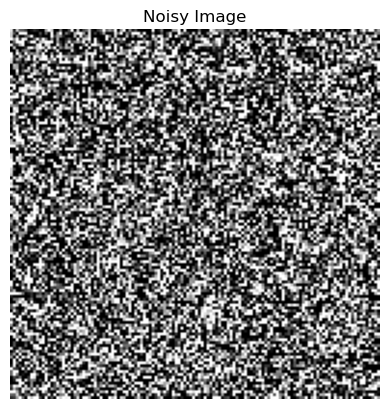

CPU times: user 66 ms, sys: 4.19 ms, total: 70.2 ms
Wall time: 69 ms


In [33]:
%%time
fast_add_gaussian_noise(img_gray, num_steps=1000, beta=0.001)

Which uses a significantly lesser time.